# Regressão Logística

### 1. Ajuste dos Parâmetros Utilizando o Gradiente Descendente

**Exemplo 1:** Suponha uma modelo que indique a probabilidade de alguem passar na disciplina de Sistemas Inteligentes baseada na quantidade de horas estudadas. Vamos treinar um modelo de regressão logística para prever a probabilidade de sucesso supondo uma determinada quantidade de horas.

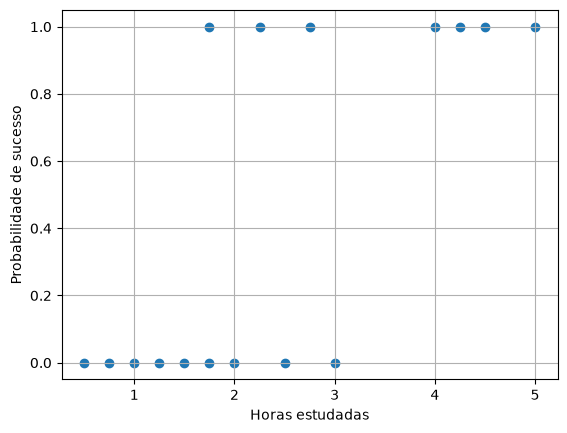

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gerando dados sintéticos: Horas de estudo vs Passar na prova (0 ou 1)
X_raw = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 4.0, 4.25, 4.5, 5.0])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1])

plt.scatter(X_raw,y)
plt.xlabel('Horas estudadas')
plt.ylabel('Probabilidade de sucesso')
plt.grid()
plt.show()

Vamos definir a função logística:

$$
h_\theta(z) = \frac{1}{1 + e^{-z}}
$$

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Definindo a função de custo:

$$
J(\theta) = -\frac{1}{N} \sum_{i=1}^{N} y^{(i)} \log\left[h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right)\right] + \left(1 - y^{(i)}\right) \log\left[1 - h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right)\right]
$$

In [3]:
def compute_cost(X, y, theta):
    N = len(y)
    z = np.dot(X, theta)
    h = sigmoid(z)
    
    # Evita log(0) adicionando um valor minúsculo (epsilon)
    epsilon = 1e-15
    cost = -(1/N) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

E por fim, vamos definir a função que implementa o gradiente descendente:

$$
\theta_j := \theta_j - \eta \frac{1}{N} \sum_{i=1}^{N} \left[ h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right) - y^{(i)} \right] x_j^{(i)}
$$

In [4]:
def gradient_descent(X, y, theta, eta, iterations):
    N, p = X.shape
    cost_history = []
    
    for i in range(iterations):
        z = np.dot(X, theta) 
        h = sigmoid(z)
        error = h - y
        ##.. for j in range(p) ...
        gradient = (1/N) * np.dot(X.T, error)
        #gradient = (1/N) * np.sum(error.T*X)
        
        theta = theta - eta * gradient
        cost_history.append(compute_cost(X, y, theta))
        
        if i % 100 == 0:
            print(f"Iteração {i}: Custo {cost_history[-1]:.4f}")
            
    return theta, cost_history

Para o algoritmo funcionar, o vetor $\mathbf{x}$ deve possuir uma coluna apenas com valores `1`:

In [5]:
X = np.column_stack((np.ones(X_raw.shape[0]), X_raw))
X

array([[1.  , 0.5 ],
       [1.  , 0.75],
       [1.  , 1.  ],
       [1.  , 1.25],
       [1.  , 1.5 ],
       [1.  , 1.75],
       [1.  , 1.75],
       [1.  , 2.  ],
       [1.  , 2.25],
       [1.  , 2.5 ],
       [1.  , 2.75],
       [1.  , 3.  ],
       [1.  , 4.  ],
       [1.  , 4.25],
       [1.  , 4.5 ],
       [1.  , 5.  ]])

Utilizando a função de treinamento:

In [6]:
eta = 0.1
iterations = 1000

theta = np.zeros(X.shape[1])                    # Inicializacao com Zeros
#theta = np.random.randn(X.shape[1])            # Inicializacao aleatória
final_theta, history = gradient_descent(X, y, theta, eta, iterations)
final_theta

Iteração 0: Custo 0.6834
Iteração 100: Custo 0.5145
Iteração 200: Custo 0.4520
Iteração 300: Custo 0.4225
Iteração 400: Custo 0.4066
Iteração 500: Custo 0.3973
Iteração 600: Custo 0.3914
Iteração 700: Custo 0.3876
Iteração 800: Custo 0.3850
Iteração 900: Custo 0.3831


array([-3.84866733,  1.51797539])

Desta forma, a equação que prevê a probabilidade de um estudante passar na prova dado uma quantidade $x$ de horas estudadas é:

$$
\hat{p} = \frac{1}{1 + e^{-(-3,85 + 1,52x)}}
$$

Podemos plotar também a curva de aprendizado, que relaciona a função de custo em função do número de iterações:

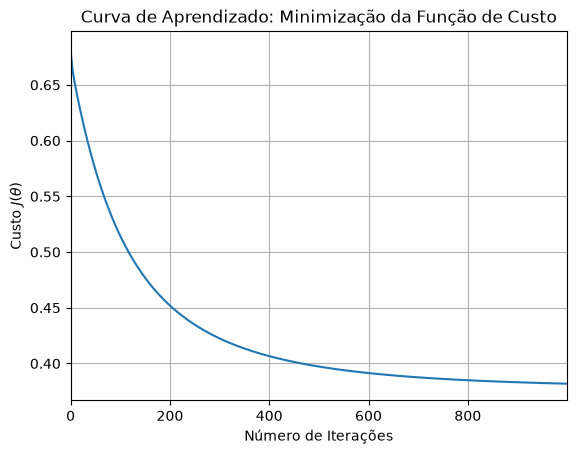

In [7]:
plt.plot(history)
plt.title('Curva de Aprendizado: Minimização da Função de Custo')
plt.xlabel('Número de Iterações')
plt.ylabel('Custo $J(\\theta)$')
plt.xlim([0, iterations-1])
plt.grid()
plt.show()

Assim sendo, se quisermos saber a probabilidade de sucesso de um estudante que estudou por 4,5 h, poderemos fazer:

In [8]:
def p_est(x):
    return sigmoid(final_theta[0] + final_theta[1]*x)

x = 4.5
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.9517644806381729


Da mesma forma, a probabilidade de sucesso de um estudante que estou somente 1 h pode ser calculada como:

In [12]:
x = 1
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.0886127662554067


Por fim, vamos apresentar o gráfico que indica a curva de probabilidade treinada em função dos dados do conjunto de treinamento:

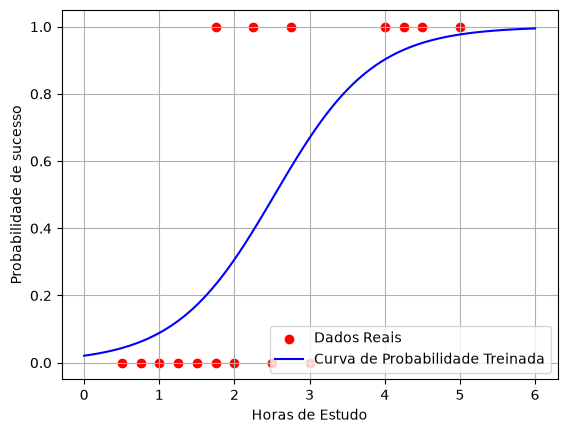

In [13]:
X_plot = np.linspace(0, 6, 100)
probabilidades = p_est(X_plot)

plt.scatter(X_raw, y, color='red', label='Dados Reais')
plt.plot(X_plot, probabilidades, color='blue', label='Curva de Probabilidade Treinada')
plt.xlabel('Horas de Estudo')
plt.ylabel('Probabilidade de sucesso')
plt.legend()
plt.grid()
plt.show()

### 2. Ajuste dos Parâmetros através da `sklearn`

Assim como na regressão linear, a biblioteca `sklearn` também apresenta os algoritmos para o ajuste dos parâmetros da regressão logística. Neste caso, utilizaremos o modelo `LogisticRegression` e utilizaremos o método `fit()` para o ajuste dos parâmetros do modelo.

**Exemplo 2:** Realize o ajuste dos parâmetros do modelo de regressão logística do Exemplo 1 utilizando a `sklearn`.

Vamos utilizar o mesmo conjunto de dados. É importante dizer que não é necessário adicionar a coluna de `1` para treinar o modelo, pois o `sklearn` já faz isso internamente:

In [15]:
from sklearn.linear_model import LogisticRegression

# Gerando dados sintéticos: Horas de estudo vs Passar na prova (0 ou 1)
X_raw = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 4.0, 4.25, 4.5, 5.0])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1])
X_raw = X_raw.reshape(-1, 1)
X_raw

array([[0.5 ],
       [0.75],
       [1.  ],
       [1.25],
       [1.5 ],
       [1.75],
       [1.75],
       [2.  ],
       [2.25],
       [2.5 ],
       [2.75],
       [3.  ],
       [4.  ],
       [4.25],
       [4.5 ],
       [5.  ]])

In [16]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_raw, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Os valores de $\theta_0$ e $\theta_1$ podem ser obtidos como:

In [17]:
t0 = model.intercept_[0]
t1 = model.coef_[0][0]

print(f"theta0 = {t0}")
print(f"theta1 = {t1}")

theta0 = -3.1385517345337437
theta1 = 1.184598083824479


Verificar que, embora os valores sejam próximos ao obtidos no Exemplo 1, os valores de $\theta_0$ e $\theta_1$ são diferentes. Isso ocorre pois a implementação do gradiente descendente da `sklearn` utiliza métodos avançados para o ajuste do passo de aprendizagem. Desta forma, a equação que prevê a probabilidade de um estudante passar na prova dado uma quantidade $x$ de horas estudadas é:

$$
\hat{p} = \frac{1}{1 + e^{-(-3,14 + 1,18x)}}
$$

Por fim, vamos apresentar o gráfico que indica a curva de probabilidade treinada em função dos dados do conjunto de treinamento:

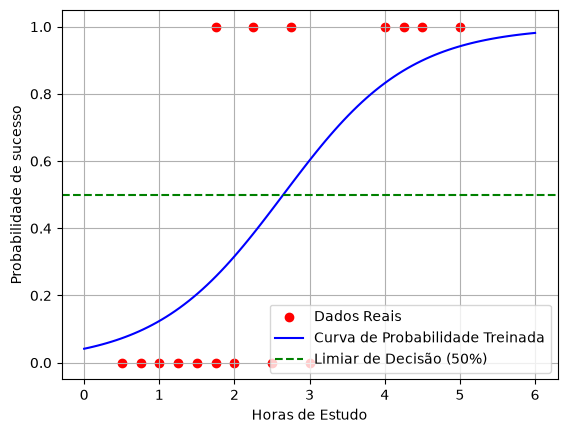

In [18]:
X_plot = np.linspace(0, 6, 100)

X_plot_mat = np.column_stack((np.ones(X_plot.shape[0]), X_plot))
probabilidades = sigmoid(np.dot(X_plot_mat, [t0, t1]))

plt.scatter(X_raw, y, color='red', label='Dados Reais')
plt.plot(X_plot, probabilidades, color='blue', label='Curva de Probabilidade Treinada')
plt.axhline(0.5, color='green', linestyle='--', label='Limiar de Decisão (50%)')
plt.xlabel('Horas de Estudo')
plt.ylabel('Probabilidade de sucesso')
plt.legend()
plt.grid()
plt.show()

Assim sendo, se quisermos saber a probabilidade de sucesso de um estudante que estudou por 4,5 h, poderemos fazer:

In [19]:
def p_est(x):
    return sigmoid(t0 + t1*x)

x = 4.5
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.8995414241373972


Da mesma forma, a probabilidade de sucesso de um estudante que estou somente 1 h pode ser calculada como:

In [21]:
x = 1
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.04154474919573722


**Exemplo 3:** Vamos utilizar uma regressão logística para classificar se um determinado achado em um exame de mama é cancerígeno ou não. As características são calculadas a partir de uma imagem digitalizada de uma amostra obtida por punção aspirativa com agulha fina de uma massa mamária. Elas descrevem as características dos núcleos celulares presentes na imagem.

Vamos importar as bibliotecas necessárias:

In [7]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve, accuracy_score, 
    precision_score, recall_score, f1_score
)

Agora vamos importar o nosso *dataset*:

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


Para uma melhor visualização, vamos transformar nossos dados em um *dataframe*:

In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


A quantidade de amostras do nosso *dataset* e a quantidade e features podem ser obtidas como: 

In [4]:
print(f"Quantidade de amostras = {X.shape[0]}")
print(f"Quantidade de features = {X.shape[1]}")

Quantidade de amostras = 569
Quantidade de features = 30


O nosso conjunto de dados possui apenas duas classes, maligno e benigno, como indicado abaixo:

In [5]:
print(data.target_names)

['malignant' 'benign']


A quantidade de amostras referentes à achados malignos e benignos são:

In [8]:
print(f"Quantidade de amostras malígnas = {np.bincount(y)[0]}")
print(f"Quantidade de amostras benigno = {np.bincount(y)[1]}")

Quantidade de amostras malígnas = 212
Quantidade de amostras benigno = 357


Vamos realizar o nosso treinamento. Inicialmente vamos dividir nosso *dataset* em conjunto de treinamento e conjunto de teste:

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 398 amostras
Teste:  171 amostras


Como estamos tratando de um problema muldimensional, é necessário realizar uma normalização dos dados. Vamos utilizar a padronização em cima do conjunto de treinamento e de teste:

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)      #Nao é necessario o fit_transform pois a media e a variancia
                                           #ja foram calculados

Agora vamos criar nosso modelo de regressão logística e realizar o treinamento:

In [11]:
model = LogisticRegression(
    max_iter=1000,     # máximo de iterações
)

model.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Finalizado o treinamento, podemos obter os parâmetros do modelo através dos atributos `intercept_` e `coef_` do modelo treinado:

In [12]:
t0 = model.intercept_
tvalues = model.coef_[0]

print(f"θ0 = {t0}")
print(f"θ1, θ2, ..., θ30 = {tvalues}")

θ0 = [0.44421352]
θ1, θ2, ..., θ30 = [-0.36619067 -0.36158121 -0.32048262 -0.41717824 -0.19220365  0.62202349
 -0.74767423 -1.1036456   0.22162459  0.13947621 -1.24418536  0.15440679
 -0.61111145 -0.86862326 -0.17719412  0.60075293 -0.08321267 -0.46939674
  0.50545235  0.69486112 -0.81452982 -1.29113423 -0.5373691  -0.77404741
 -0.49635091  0.11840842 -0.97487392 -0.80805037 -1.20249734 -0.10324298]


Após treinado o modelo, poderemos utilizar-ló para realizar a previsão para novos valores. Neste caso, vamos salvar o vetor de parâmetros $\mathbb{\Phi}$ e utilizar a expressão da regressão logística para determinar a probabilidade do achado ser benigno. Relembrando que a probabilidade pode ser calculada como:

$$
\hat{p} = \frac{1}{1 + e^{-\mathbf{x}^T\Phi} }
$$

Após isso, poderemos fazer um teste de hipótese:
* Se $\hat{p} < 0,5$, então o achado é malígno;
* Se $\hat{p} \geq 0,5$, então o achado é benigno.

In [13]:
theta = np.concatenate((t0, tvalues))
theta

array([ 0.44421352, -0.36619067, -0.36158121, -0.32048262, -0.41717824,
       -0.19220365,  0.62202349, -0.74767423, -1.1036456 ,  0.22162459,
        0.13947621, -1.24418536,  0.15440679, -0.61111145, -0.86862326,
       -0.17719412,  0.60075293, -0.08321267, -0.46939674,  0.50545235,
        0.69486112, -0.81452982, -1.29113423, -0.5373691 , -0.77404741,
       -0.49635091,  0.11840842, -0.97487392, -0.80805037, -1.20249734,
       -0.10324298])

In [15]:
def model_predict(theta, x):
    z = np.dot(x,theta)
    p = sigmoid(z)
    status = 'malignant' if p < 0.5 else 'benign'
    return status, p

Vamos utilizar a nossa função para determinar se a oitava amostra do conjunto de teste corresponde à um achado malígno ou benigno:

In [16]:
X_example = np.concatenate(([1],X_test_sc[7]))

status, p = model_predict(theta, X_example)
print(f"Previsão = {status}\nProbabilidade (benigno) = {p*100:.2f}%")

Previsão = malignant
Probabilidade (benigno) = 4.30%


Da mesma forma, poderemos determinar se a 15ª amostra do conjunto de teste é um achado malígno ou benigno:

In [17]:
X_example = np.concatenate(([1],X_test_sc[14]))

status, p = model_predict(theta, X_example)
print(f"Previsão = {status}\nProbabilidade (benigno) = {p*100:.2f}%")

Previsão = benign
Probabilidade (benigno) = 99.78%


De forma geral, poderemos utilizar o método `predict` do modelo treinado para determinar a saída do modelo para uma dada entrada. Desta forma, poderemos determinar a saída considerando todo o conjunto de teste através de:

In [18]:
y_pred = model.predict(X_test_sc)

As probabilidades associadas podem ser calculadas como:

In [19]:
y_prob = model.predict_proba(X_test_sc)[:, 1]

De forma a verificar a capacidade de generalização do nosso modelo, podemos utilizar a função `confusion_matrix` para determinar a matriz de confusão:

In [20]:
print(confusion_matrix(y_test, y_pred))

[[ 62   1]
 [  2 106]]


Analisando a matriz de confusão:
* 62 casos de achados malígnos foram corretamente detectados;
* 1 caso de achado malígno foi classificado como benigno;
* 2 caso de achado benigno foi classificado como malígno;
* 106 casos de achados begninos foram corretamente classificados.

Podemos agora calcular as métricas de desempenho do nosso classificador utilizando as funções `accuracy_score`, `precision_score`, `recall_score` e `f1_score`:

In [21]:
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

Acurácia: 0.9825
Precisão: 0.9907
Recall: 0.9815
F1-Score: 0.9860


A curva ROC e o valor do AUC podem ser obtidos através das funções `roc_curve` e `roc_auc_score`:

AUC-ROC:  0.9979


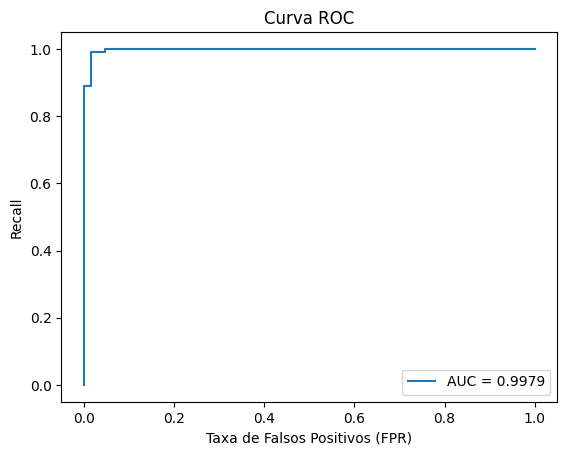

In [23]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")

# Plotar
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Recall')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [24]:
thresholds

array([           inf, 9.99999884e-01, 9.34785959e-01, 9.26886878e-01,
       4.81181384e-01, 3.78030213e-01, 2.24668067e-01, 1.03443618e-12])

### 3. Regularização e Validação Cruzada

**Exemplo 4:** Vamos aplicar os conceitos de regularização e validação cruzada para o modelo de regressão linear do Exemplo 3.

Inicialmente vamos criar um dicionário com diversos parâmetros:

In [34]:
configs = [
    {'l1_ratio': 1, 'C': 0.01, 'solver': 'liblinear'}, #liblinear
    {'l1_ratio': 1, 'C': 0.1,  'solver': 'liblinear'},
    {'l1_ratio': 1, 'C': 1.0,  'solver': 'liblinear'},
    {'l1_ratio': 1, 'C': 10,   'solver': 'liblinear'},
    {'l1_ratio': 0, 'C': 0.01, 'solver': 'lbfgs'},
    {'l1_ratio': 0, 'C': 0.1,  'solver': 'lbfgs'},
    {'l1_ratio': 0, 'C': 1.0,  'solver': 'lbfgs'},
    {'l1_ratio': 0, 'C': 10,   'solver': 'lbfgs'},
]
# l1_ratio=0 --> Regularização L2
# l1_ratio=1 --> Regularização L1
# Obs: C = 1/a. Então valores altos de C indicam pouca regularização
# Grid Search

Agora vamos treinar um modelo de regressão logística com esses diversos parâmetros:

In [35]:
from sklearn.model_selection import cross_val_score
score_mean = np.zeros(len(configs))

for idx, cfg in enumerate(configs):
    m = LogisticRegression(max_iter=1000, random_state=42, **cfg)
    scores = cross_val_score(m, X_train_sc, y_train, cv=5)
    penalty_label = 'l1' if cfg['l1_ratio'] == 1 else 'l2'
    print(f"Penalidade = {penalty_label}, C = {cfg['C']:6} | "
          f"Acurácia: {scores.mean():.4f} ± {scores.std():.4f}")
    score_mean[idx] = scores.mean()

best_cfg = configs[np.argmax(score_mean)]
print(f"\nMelhor configuração = {best_cfg}")

Penalidade = l1, C =   0.01 | Acurácia: 0.9047 ± 0.0420
Penalidade = l1, C =    0.1 | Acurácia: 0.9648 ± 0.0094
Penalidade = l1, C =    1.0 | Acurácia: 0.9748 ± 0.0160
Penalidade = l1, C =     10 | Acurácia: 0.9773 ± 0.0168
Penalidade = l2, C =   0.01 | Acurácia: 0.9472 ± 0.0097
Penalidade = l2, C =    0.1 | Acurácia: 0.9723 ± 0.0096
Penalidade = l2, C =    1.0 | Acurácia: 0.9748 ± 0.0139
Penalidade = l2, C =     10 | Acurácia: 0.9722 ± 0.0218

Melhor configuração = {'l1_ratio': 1, 'C': 10, 'solver': 'liblinear'}


Após isso, vamos treinar o modelo com a melhor configuração:

In [27]:
# Treinar o modelo final com todos os dados de treino
best_model = LogisticRegression(max_iter=1000, random_state=42, **best_cfg)
best_model.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicla

E vamos avaliar para o conjunto de testes:

In [28]:
# Avaliar no conjunto de teste
y_pred = best_model.predict(X_test_sc)
y_prob = best_model.predict_proba(X_test_sc)[:, 1]

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")

Acurácia: 0.9649
Precisão: 0.9904
Recall: 0.9537
F1-Score: 0.9717
AUC-ROC:  0.9928
